In [ ]:
!pip install qiskit
!pip install qiskit-aer
!pip install matplotlib pylatexenc


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 85.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=2b28b3d57fd5204e0b75aaf632a59f1fde3c3e0aff1a999dd301b22b0e6a9788
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


counts: {'10': 1024}


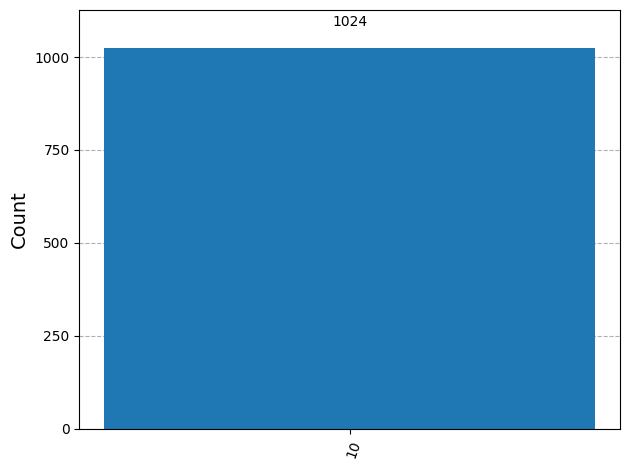

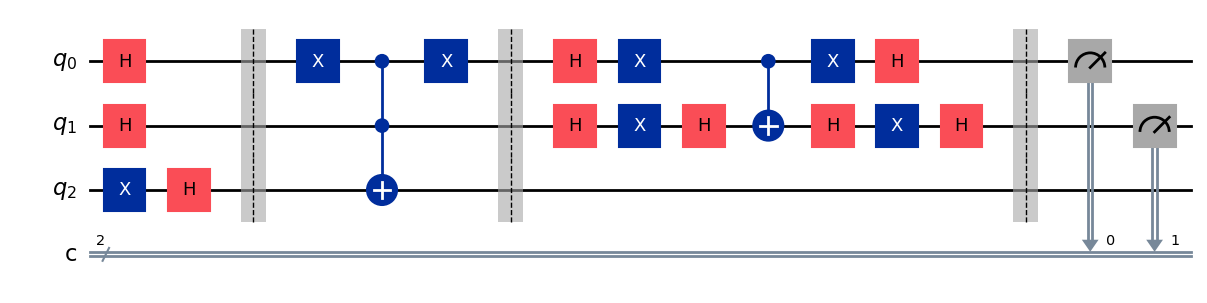

In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

#initialising qubit

qc=QuantumCircuit(3,2)
qc.x(2)
qc.h(2)

qc.h(0) #preparing main qubits for superposition
qc.h(1)

qc.barrier()

#Oracle
# The target is |10> (qubit 1 = 1, qubit 0 = 0).
# To mark '10', we want the Toffoli (CCX,control control x) to trigger only when q1=1 and q0=0.
# So we flip q0 to 1 temporarily, trigger, and flip it back.
qc.x(0)
qc.ccx(0,1,2)
qc.x(0)
qc.barrier()

#amplitude amplification for 10
qc.h(0)
qc.h(1) #superposed state return back to zero basis state 00
qc.x(0)
qc.x(1) # flip bits from 00 to 11

#apply cz to flip sign of 11
qc.h(1) #prepare for phase kickback
qc.cx(0,1)
qc.h(1)

qc.x(0)
qc.x(1)
qc.h(0)
qc.h(1) # return back to superposed state

qc.barrier()

#measurement
qc.measure([0,1],[0,1])

simulator=AerSimulator()
job=simulator.run(qc,shots=1024)
result=job.result()
counts=result.get_counts()

print("counts:",counts)
histogram=plot_histogram(counts)
display(histogram)
display(qc.draw("mpl"))




